# 黄河干旱

In [1]:
#!/usr/bin/env python 3.83
# -*-coding:utf-8 -*-
# Created date: 2021-21-27
# @Author  : Shuang Song
# @Contact   : SongshGeo@gmail.com
# GitHub   : https://github.com/SongshGeo
# Research Gate: https://www.researchgate.net/profile/Song_Shuang9

# 常用的软件包
import sys, os  # 系统路径工具
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# 添加上级目录
sys.path.append('..')

# 显示绘图
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.facecolor'] = 'white'

# 自定义配色
nature_colors = {
    'NS': "#c83c1c",
    'Nature': "#29303c",
    'NCC': "#0889a6",
    'NC': "#f1801f",
    'NG': "#006c43",
    'NHB': "#1951A0",
    'NEE': "#C7D530"
}

In [2]:
history = pd.read_csv("dro and flo for 50 years.csv", index_col=0)
history.head()

,Drought,Flood,Reliability
Years,,,
-125,1,1,2
-75,6,1,1
-25,4,3,1
25,5,4,1
75,6,1,3


In [3]:
now = pd.read_excel("干旱严重程度.xlsx", index_col=0)
now.head()

,SPEI_1 month lag,SPEI_3 month lag,SPEI_6 month lag,SPEI_12 month lag
1957,0.73270,0.61161,0.47149,0.34318
1958,0.37675,0.23654,0.44524,0.42753
1959,0.38370,0.19282,0.08789,0.01449
1960,0.64702,0.42412,0.41244,0.28636
1961,0.10041,0.10425,0.06347,0.09571


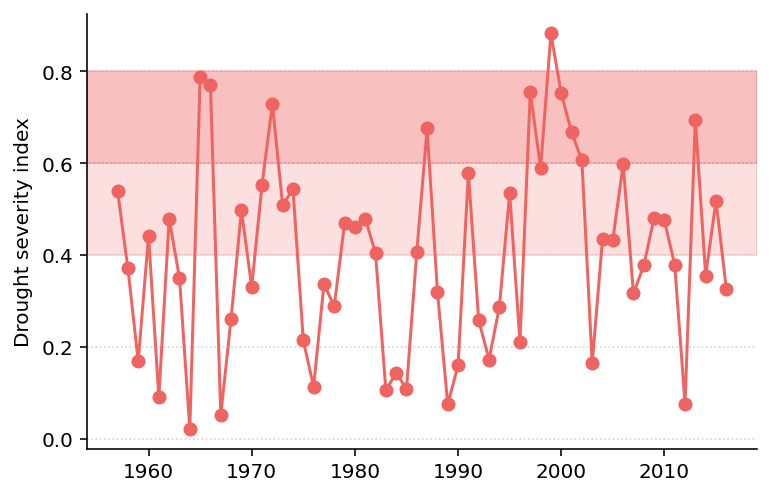

In [4]:
def recent_drought(ax=None):
    if not ax:
        fig, ax = plt.subplots()
    ax.plot(now.index, now.mean(axis=1), '-o', color='#EF6461')
    ax.set_ylabel('Drought severity index')
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(ls=":", color='lightgray')
    ax.axhspan(0.6, 0.8, color='#EF6461', alpha=.4)
    ax.axhspan(0.4, 0.6, color='#EF6461', alpha=.2)
    return ax

ax = recent_drought()

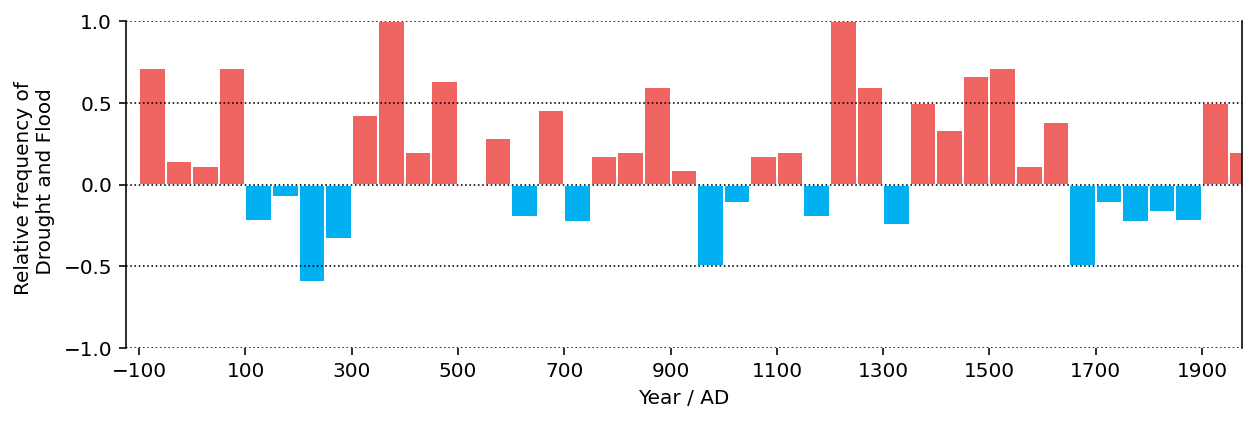

In [5]:
drought_ratio = ((history['Drought'] - history['Flood'])/(history['Drought'] + history['Flood']))

def historical_drought(ax=None):
    if not ax:
        fig, ax = plt.subplots(figsize=(10, 3))
    colors = ['#EF6461' if ratio > 0 else '#00b0f0' for ratio in drought_ratio]
    ax.bar(drought_ratio.index, drought_ratio, width=50, color=colors, edgecolor='white')
    ax.set_xlabel("Year / AD")
#     ax.xaxis.tick_top()
    ax.yaxis.grid(ls=":", color='black')
    ax.set_xticks(np.arange(-100, 2001, 200))
    ax.set_xlim(drought_ratio.index.min(), drought_ratio.index.max())
    ax.set_yticks(np.arange(-1, 1.1, 0.5))
    ax.set_ylim(-1, 1)
    ax.spines[['bottom', 'top']].set_visible(False)
    ax.set_ylabel("Relative frequency of \n Drought and Flood")
#     ax.axvspan(1950, 2000, color='gray', alpha=.4)
#     ax.axvline(1950, ls=":", color='black')
    return ax

historical_drought()
plt.show();

<AxesSubplot:xlabel='Annual runoff'>

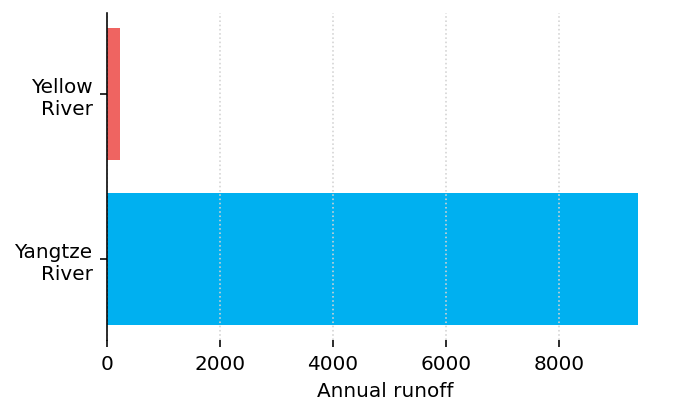

In [6]:
def compare(ax=None):
    if not ax:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.barh([0, 1], [9397, 239], color=['#00b0f0', '#ef6461'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Yangtze\nRiver', 'Yellow\nRiver'])
    ax.spines[['bottom', 'top', 'right']].set_visible(False)
    ax.xaxis.grid(color='lightgray', ls=':')
    ax.set_xlabel("Annual runoff")
    return ax

compare()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


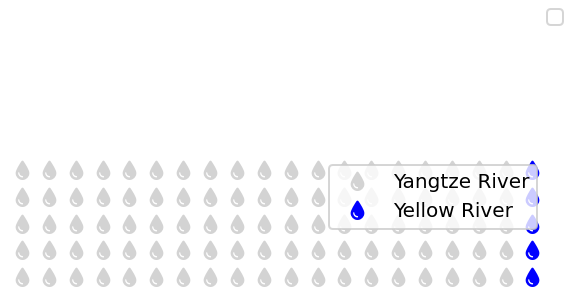

In [7]:
from pywaffle import Waffle

fig = plt.figure(
    figsize=(4, 3), 
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=[95, 5],
    colors=["lightgray", "blue"],
    icons='droplet',
#     icon_style='light',
    icon_legend=True,
    font_size=10,
    labels=['Yangtze River', 'Yellow River']
)
fig.legend()

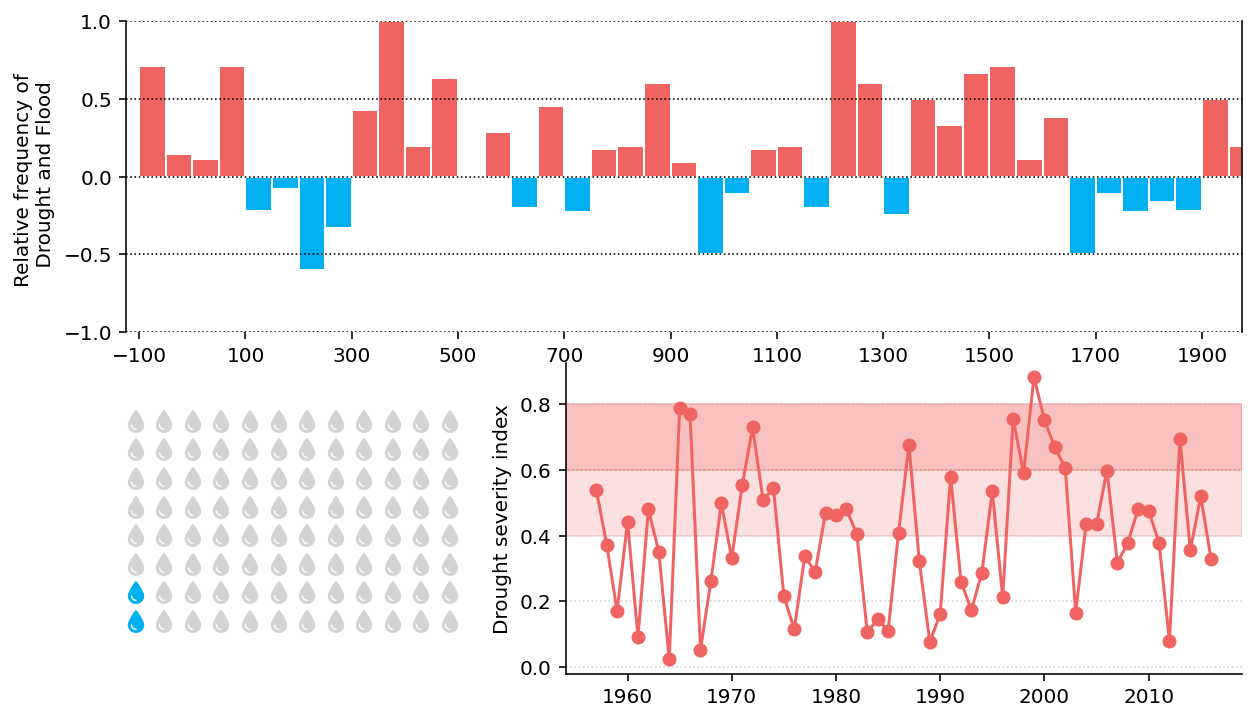

In [12]:
fig = plt.figure(figsize=(10, 6), constrained_layout=False)
height = [1, 1]
width = [1, 2]
gs = fig.add_gridspec(ncols=2, nrows=2, height_ratios=height, width_ratios=width, hspace=0.1, wspace=0.2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])

ax1 = historical_drought(ax1)
ax3 = recent_drought(ax3)

def waffle_compare(ax=None):
    if not ax:
        fig, ax = plt.subplots()
    # Modify existed axis
    ax.set_aspect(aspect="equal")

    Waffle.make_waffle(
        ax=ax,  # pass axis to make_waffle
        rows=8, 
        columns=12, 
        colors=["#00b0f0", "lightgray"],
        icons='droplet',
        values=[239, 9397], 
    #     title={"label": "YR v.s. YzR:", "loc": "left"}
    )
    return ax2

ax2 = waffle_compare(ax2)
plt.savefig('YR_drought.jpg', dpi=300, bbox_inches='tight')

## Plan A

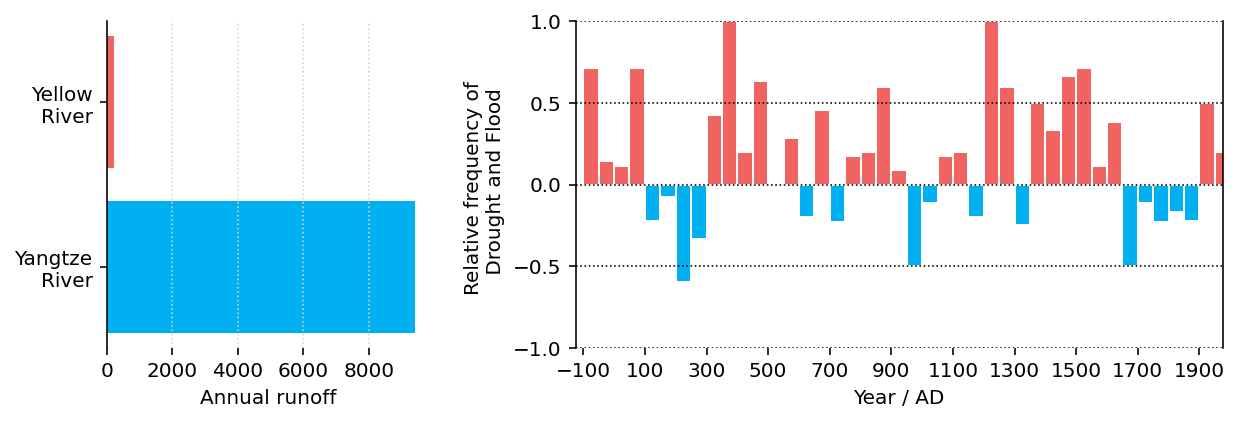

In [16]:
fig = plt.figure(figsize=(10, 3), constrained_layout=False)
width = [1, 2]
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=width, wspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1 = compare(ax1)
ax2 = historical_drought(ax2)
plt.savefig('YR_drought_planA.png', dpi=300, bbox_inches='tight')

## Plan B

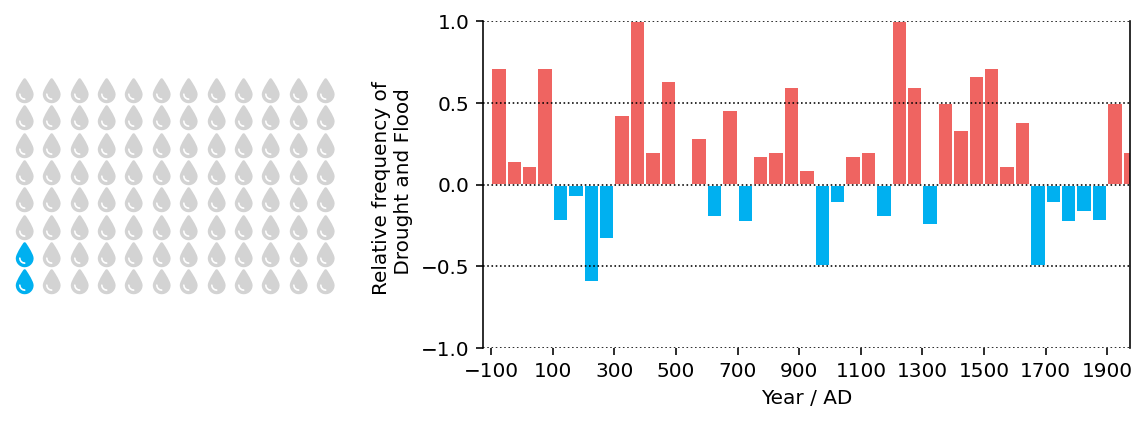

In [14]:
fig = plt.figure(figsize=(10, 3), constrained_layout=False)
width = [1, 2]
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=width, wspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1 = waffle_compare(ax1)
ax2 = historical_drought(ax2)
plt.savefig('YR_drought_planB.png', dpi=300, bbox_inches='tight')

In [15]:
!open .